## Import Libraries and Device Setup

In [58]:
# ==========================================
# Step 1 - Import Libraries and Device Setup
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Device Setup
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using Device:", device)

# Speed Optimization
torch.backends.cudnn.benchmark = True

Using Device: cpu


## Load Dataset

In [59]:
# ==========================================
# Step 2 - Load Dataset
# ==========================================

df = pd.read_csv("../../data/indoorAir2.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    unit="s"
)

# Sort by station and time
df = df.sort_values(
    ["station_id", "timestamp"]
).reset_index(drop=True)

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nStation Counts:")
print(df["station_id"].value_counts().sort_index())

Dataset Shape:
(1924653, 21)

Columns:
['id', 'station_id', 'station_name', 'timestamp', 'scd41_co2', 'scd41_temperature', 'scd41_humidity', 'ens160_eco2', 'ens160_tvoc', 'ens160_aqi', 'svm41_temperature', 'svm41_humidity', 'svm41_nox_index', 'svm41_voc_index', 'bme688_temperature', 'bme688_humidity', 'bme688_pressure', 'bme688_gas_resistance', 'sfa30_temperature', 'sfa30_humidity', 'sfa30_hco']

Station Counts:
station_id
1    586547
2    174666
3    361836
4    549339
5    252261
6         4
Name: count, dtype: int64


## Remove Station 6

In [60]:
# ==========================================
# Step 3 - Remove Station 6
# ==========================================

df = df[df["station_id"] != 6].copy()

print("Shape After Removing Station 6:")
print(df.shape)

print("\nRemaining Stations:")
print(sorted(df["station_id"].unique()))

print("\nStation Counts:")
print(df["station_id"].value_counts().sort_index())

Shape After Removing Station 6:
(1924649, 21)

Remaining Stations:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Station Counts:
station_id
1    586547
2    174666
3    361836
4    549339
5    252261
Name: count, dtype: int64


## Create Cyclic Time Features

In [61]:
# ==========================================
# Step 4 - Cyclic Time Features
# ==========================================

# Extract time information
hour = (
    df["timestamp"].dt.hour
    + df["timestamp"].dt.minute / 60
)

dayofweek = df["timestamp"].dt.dayofweek

# Hour cyclic encoding
df["hour_sin"] = np.sin(
    2 * np.pi * hour / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * hour / 24
)

# Day-of-week cyclic encoding
df["dayofweek_sin"] = np.sin(
    2 * np.pi * dayofweek / 7
)

df["dayofweek_cos"] = np.cos(
    2 * np.pi * dayofweek / 7
)

# Weekend indicator
df["is_weekend"] = (
    dayofweek.isin([5, 6]).astype(int)
)

print("Cyclic Features Created Successfully")

print("\nNew Columns:")
print([
    "hour_sin",
    "hour_cos",
    "dayofweek_sin",
    "dayofweek_cos",
    "is_weekend"
])

print("\nShape:")
print(df.shape)

Cyclic Features Created Successfully

New Columns:
['hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_weekend']

Shape:
(1924649, 26)


## Create Feature Dataset.

In [62]:
# ==========================================
# Step 5 - Create Feature Dataset
# ==========================================

feature_df = df[
    [
        "ens160_aqi",
        "ens160_tvoc",
        "bme688_gas_resistance",
        "bme688_pressure",
        "scd41_temperature",
        "scd41_humidity",
        "timestamp",
        "scd41_co2",
        "hour_sin",
        "hour_cos",
        "dayofweek_sin",
        "dayofweek_cos",
        "is_weekend",
        "station_id",
    ]
].copy()

print("Feature Data Shape:")
print(feature_df.shape)

print("\nColumns:")
print(feature_df.columns.tolist())

feature_df.head()

Feature Data Shape:
(1924649, 14)

Columns:
['ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'timestamp', 'scd41_co2', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_weekend', 'station_id']


,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,timestamp,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend,station_id
0,1,32,NaN,NaN,22.951857,36.897277,2024-11-13 16:57:56,488.0,-0.962455,-0.271440,0.974928,-0.222521,0,1
1,1,30,NaN,NaN,22.335011,38.185119,2024-11-13 16:58:57,485.0,-0.963630,-0.267238,0.974928,-0.222521,0,1
2,1,43,NaN,NaN,22.353704,38.400268,2024-11-13 16:59:59,477.0,-0.964787,-0.263031,0.974928,-0.222521,0,1
3,1,26,NaN,NaN,22.417792,38.269042,2024-11-13 17:01:03,474.0,-0.967046,-0.254602,0.974928,-0.222521,0,1
4,1,31,NaN,NaN,22.556649,37.971496,2024-11-13 17:02:05,473.0,-0.968148,-0.250380,0.974928,-0.222521,0,1


## Resample Each Station to 15 Minutes

In [63]:
# ==========================================
# Step 7 - Resample to 15 Minutes
# ==========================================

feature_df["timestamp"] = pd.to_datetime(
    feature_df["timestamp"]
)

feature_df = feature_df.set_index(
    "timestamp"
)

station_data = []

for station in feature_df["station_id"].unique():

    station_df = feature_df[
        feature_df["station_id"] == station
    ].copy()

    station_df = station_df.resample(
        "15min"
    ).mean()

    station_df["station_id"] = station

    station_data.append(
        station_df
    )

feature_df = pd.concat(
    station_data
)

print("Shape After Resampling:")
print(feature_df.shape)

feature_df.head()

Shape After Resampling:
(186889, 13)


,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend,station_id
timestamp,,,,,,,,,,,,,
2024-11-13 16:45:00,1.0,35.000000,NaN,NaN,22.546857,37.827555,483.333333,-0.963624,-0.267237,0.974928,-0.222521,0.0,1
2024-11-13 17:00:00,1.0,26.857143,NaN,NaN,22.746242,37.604195,472.285714,-0.970259,-0.241913,0.974928,-0.222521,0.0,1
2024-11-13 17:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2024-11-13 17:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2024-11-13 17:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [64]:
print(feature_df.shape)

feature_df.isna().sum().sort_values(
    ascending=False
).head(10)

(186889, 13)


bme688_gas_resistance    53805
bme688_pressure          53805
ens160_aqi               50832
ens160_tvoc              50832
scd41_temperature        50832
scd41_humidity           50832
scd41_co2                50832
hour_sin                 50832
hour_cos                 50832
dayofweek_sin            50832
dtype: int64

## Handle Missing Values

In [65]:
# ==========================================
# Step 7 - Missing Value Handling
# ==========================================

feature_df = feature_df.interpolate(
    method="time"
)

feature_df = feature_df.ffill()

feature_df = feature_df.bfill()

print(
    "Remaining Missing Values:",
    feature_df.isna().sum().sum()
)

print(
    "Shape After Missing Value Handling:"
)

print(feature_df.shape)

Remaining Missing Values: 0
Shape After Missing Value Handling:
(186889, 13)


## Time-Based Split

In [66]:
# ==========================================
# Step 8 - Time-Based Split
# ==========================================

feature_df = feature_df.sort_index()

n = len(feature_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = feature_df.iloc[:train_end]
val_df = feature_df.iloc[train_end:val_end]
test_df = feature_df.iloc[val_end:]

print("Train Shape :", train_df.shape)
print("Val Shape   :", val_df.shape)
print("Test Shape  :", test_df.shape)

print("\nTimestamp Ranges")

print(
    "Train:",
    train_df.index.min(),
    "->",
    train_df.index.max()
)

print(
    "Val:",
    val_df.index.min(),
    "->",
    val_df.index.max()
)

print(
    "Test:",
    test_df.index.min(),
    "->",
    test_df.index.max()
)

Train Shape : (130822, 13)
Val Shape   : (28033, 13)
Test Shape  : (28034, 13)

Timestamp Ranges
Train: 2024-11-13 16:45:00 -> 2025-10-26 14:00:00
Val: 2025-10-26 14:00:00 -> 2026-01-15 05:00:00
Test: 2026-01-15 05:00:00 -> 2026-04-22 13:00:00


print(train_df["station_id"].value_counts())
print("\n")
print(val_df["station_id"].value_counts())
print("\n")
print(test_df["station_id"].value_counts())

#  Feature Scaling

In [67]:
from sklearn.preprocessing import MinMaxScaler

feature_columns = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",
    "hour_sin",
    "hour_cos",
    "dayofweek_sin",
    "dayofweek_cos",
    "is_weekend"
]

target_column = "scd41_co2"

In [68]:
scaler = MinMaxScaler()

train_scaled = train_df.copy()
val_scaled = val_df.copy()
test_scaled = test_df.copy()

train_scaled[feature_columns] = scaler.fit_transform(
    train_df[feature_columns]
)

val_scaled[feature_columns] = scaler.transform(
    val_df[feature_columns]
)

test_scaled[feature_columns] = scaler.transform(
    test_df[feature_columns]
)

In [69]:
print("Train Shape :", train_scaled.shape)
print("Validation Shape :", val_scaled.shape)
print("Test Shape :", test_scaled.shape)

print("\nTrain Feature Minimum Values")
print(train_scaled[feature_columns].min())

print("\nTrain Feature Maximum Values")
print(train_scaled[feature_columns].max())

Train Shape : (130822, 13)
Validation Shape : (28033, 13)
Test Shape : (28034, 13)

Train Feature Minimum Values
ens160_aqi               0.0
ens160_tvoc              0.0
bme688_gas_resistance    0.0
bme688_pressure          0.0
scd41_temperature        0.0
scd41_humidity           0.0
scd41_co2                0.0
hour_sin                 0.0
hour_cos                 0.0
dayofweek_sin            0.0
dayofweek_cos            0.0
is_weekend               0.0
dtype: float64

Train Feature Maximum Values
ens160_aqi               1.0
ens160_tvoc              1.0
bme688_gas_resistance    1.0
bme688_pressure          1.0
scd41_temperature        1.0
scd41_humidity           1.0
scd41_co2                1.0
hour_sin                 1.0
hour_cos                 1.0
dayofweek_sin            1.0
dayofweek_cos            1.0
is_weekend               1.0
dtype: float64


## sequence generation

In [70]:
import numpy as np

# Parameters
SEQ_LENGTH = 72     # Past 12 hours
OUTPUT_LENGTH = 12   # Next 3 hours

target_column = "scd41_co2"
target_idx = feature_columns.index(target_column)

# Station-wise sequence creation
def create_sequences_stationwise(
    df,
    feature_columns,
    target_idx,
    seq_length,
    output_length
):
    X, y = [], []

    for station_id in sorted(df["station_id"].unique()):

        station_df = df[df["station_id"] == station_id]

        data = station_df[feature_columns].values

        for i in range(len(data) - seq_length - output_length):

            X.append(data[i:i + seq_length])

            y.append(
                data[
                    i + seq_length :
                    i + seq_length + output_length,
                    target_idx
                ]
            )

    return np.array(X), np.array(y)


# Create sequences
X_train, y_train = create_sequences_stationwise(
    train_scaled,
    feature_columns,
    target_idx,
    SEQ_LENGTH,
    OUTPUT_LENGTH
)

X_val, y_val = create_sequences_stationwise(
    val_scaled,
    feature_columns,
    target_idx,
    SEQ_LENGTH,
    OUTPUT_LENGTH
)

X_test, y_test = create_sequences_stationwise(
    test_scaled,
    feature_columns,
    target_idx,
    SEQ_LENGTH,
    OUTPUT_LENGTH
)

# Check shapes
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (130402, 72, 12)
y_train: (130402, 12)
X_val: (27697, 72, 12)
y_val: (27697, 12)
X_test: (27782, 72, 12)
y_test: (27782, 12)


## PyTorch Dataset & DataLoader

In [71]:
import torch
from torch.utils.data import Dataset, DataLoader

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)
test_dataset = TimeSeriesDataset(X_test, y_test)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

Train batches: 1019
Validation batches: 217
Test batches: 218

X_train shape: torch.Size([130402, 72, 12])
y_train shape: torch.Size([130402, 12])


## Transformer Model

In [74]:
import math
import torch
import torch.nn as nn


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(
            0,
            max_len,
            dtype=torch.float
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(
                0,
                d_model,
                2
            ).float()
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TransformerModel(nn.Module):
    def __init__(
        self,
        input_dim,
        output_length,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0.2
    ):
        super().__init__()

        self.input_projection = nn.Linear(
            input_dim,
            d_model
        )

        self.positional_encoding = PositionalEncoding(
            d_model
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            d_model,
            output_length
        )

    def forward(self, x):

        x = self.input_projection(x)

        x = self.positional_encoding(x)

        x = self.transformer_encoder(x)

        x = x[:, -1, :]

        x = self.dropout(x)

        return self.fc(x)

## Initialize Model

In [75]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

model = TransformerModel(
    input_dim=len(feature_columns),
    output_length=OUTPUT_LENGTH,
    d_model=128,
    nhead=4,
    num_layers=2,
    dropout=0.2
).to(device)

print(model)

Device: cpu
TransformerModel(
  (input_projection): Linear(in_features=12, out_features=128, bias=True)
  (positional_encoding): PositionalEncoding()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=2048, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=2048, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=12, bias=True)
)


## Loss Function, Optimizer & Scheduler

In [76]:
import torch.optim as optim

criterion = nn.HuberLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

print("Loss Function :", criterion)
print("Optimizer     :", optimizer.__class__.__name__)

Loss Function : HuberLoss()
Optimizer     : AdamW


## Training Loop

In [77]:
EPOCHS = 8

best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(predictions, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)

            loss = criterion(predictions, y_batch)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_transformer.pth"
        )

        print("Best model saved!")

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.6f} "
        f"| Validation Loss: {val_loss:.6f}"
    )

print("\nTraining Finished!")

Best model saved!
Epoch [1/8] | Train Loss: 0.004480 | Validation Loss: 0.001877
Best model saved!
Epoch [2/8] | Train Loss: 0.000840 | Validation Loss: 0.001837
Epoch [3/8] | Train Loss: 0.000765 | Validation Loss: 0.001893
Epoch [4/8] | Train Loss: 0.000722 | Validation Loss: 0.001885
Epoch [5/8] | Train Loss: 0.000693 | Validation Loss: 0.001911
Best model saved!
Epoch [6/8] | Train Loss: 0.000675 | Validation Loss: 0.001795
Epoch [7/8] | Train Loss: 0.000670 | Validation Loss: 0.001902
Best model saved!
Epoch [8/8] | Train Loss: 0.000656 | Validation Loss: 0.001791

Training Finished!


##  Transformer Evaluation

In [86]:
import numpy as np

predictions = []

with torch.no_grad():

    for X_batch, _ in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predictions.append(
            outputs.cpu().numpy()
        )

y_pred = np.concatenate(predictions, axis=0)

y_true = y_test.numpy()

print("Prediction Shape:", y_pred.shape)
print("True Shape:", y_true.shape)

Prediction Shape: (27782, 12)
True Shape: (27782, 12)


## Inverse Transform CO₂

In [87]:
co2_min = scaler.data_min_[target_idx]
co2_max = scaler.data_max_[target_idx]

y_pred_inv = y_pred * (co2_max - co2_min) + co2_min
y_true_inv = y_true * (co2_max - co2_min) + co2_min

print("Inverse Scaling Complete")

Inverse Scaling Complete


In [90]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(
    y_true.flatten(),
    y_pred.flatten()
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_true.flatten(),
    y_pred.flatten()
)

r2 = r2_score(
    y_true.flatten(),
    y_pred.flatten()
)

print("\nTransformer Model Evaluation Metrics")
print(f"MSE      : {mse:.6f}")
print(f"RMSE     : {rmse:.6f}")
print(f"MAE      : {mae:.6f}")
print(f"R² Score : {r2:.6f}")


Transformer Model Evaluation Metrics
MSE      : 0.001882
RMSE     : 0.043384
MAE      : 0.015970
R² Score : 0.694034


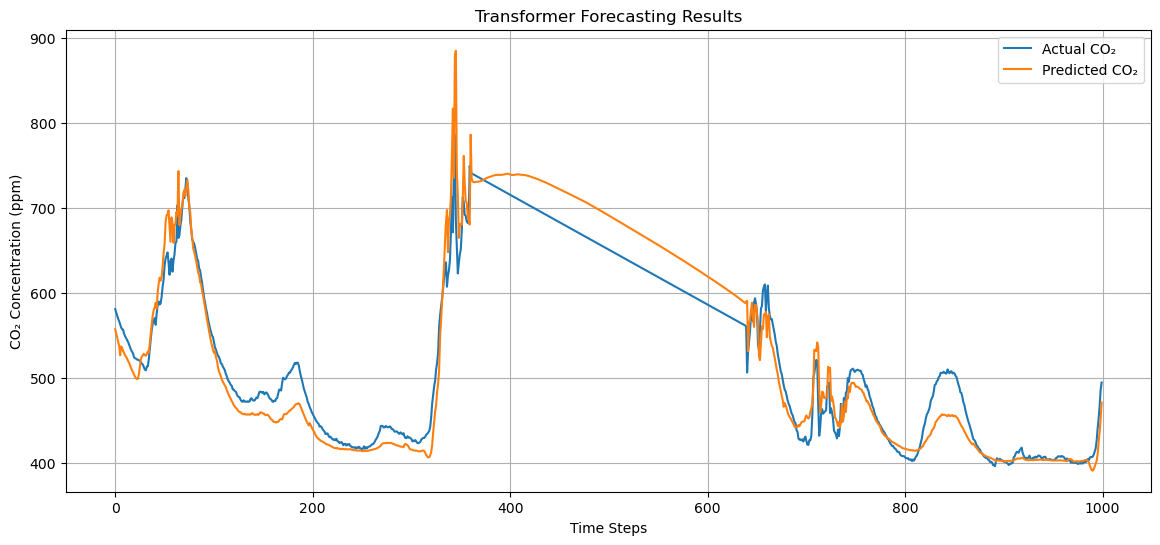

In [91]:
import matplotlib.pyplot as plt

# First forecast horizon
actual = y_true_inv[:, 0]
predicted = y_pred_inv[:, 0]

plt.figure(figsize=(14, 6))

plt.plot(actual[:1000], label="Actual CO₂")
plt.plot(predicted[:1000], label="Predicted CO₂")

plt.title("Transformer Forecasting Results")
plt.xlabel("Time Steps")
plt.ylabel("CO₂ Concentration (ppm)")
plt.legend()
plt.grid(True)

plt.show()

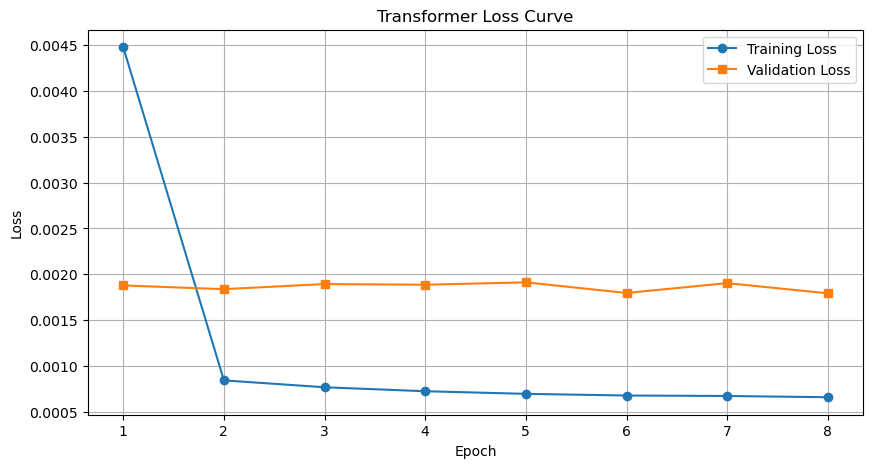

In [85]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))

plt.plot(epochs, train_losses, marker='o', label='Training Loss')
plt.plot(epochs, val_losses, marker='s', label='Validation Loss')

plt.title('Transformer Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.show()